# VAE - ArtBench

https://www.geeksforgeeks.org/machine-learning/variational-autoencoders/

## Setup

In [41]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

In [42]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [43]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Dataset

In [44]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = C:\Users\Jose\Mestrado\IAG_TP1
SCRIPTS_DIR    = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10
TRAINING CSV   = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [45]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [46]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [47]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5), # Inverte a pintura lateralmente
    #transforms.RandomRotation(degrees=10),  # Roda até 10 graus
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [48]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [49]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [50]:
#train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)
train_full = HFDatasetTorch(train_dataset_completo, transform=transform)
train_loader = DataLoader(
    train_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_full))
print("Número de batches:", len(train_loader))


Tamanho do subset: 50000
Número de batches: 782


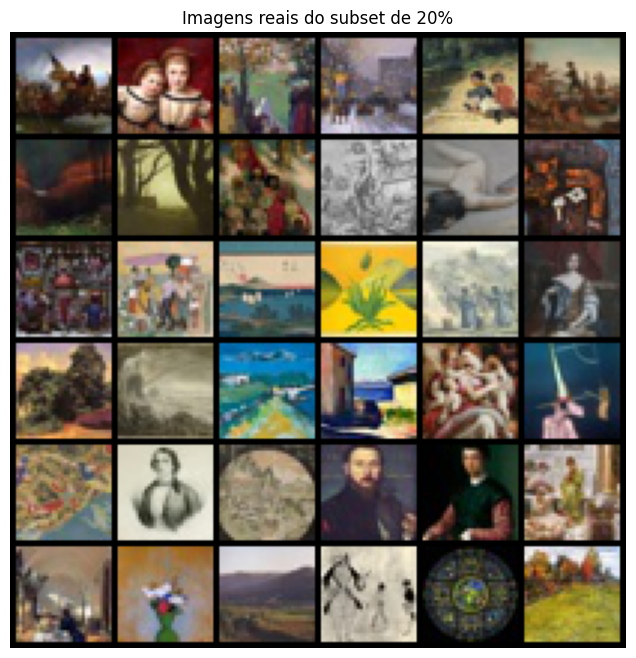

Exemplos de labels:
0: classe=romanticism 
1: classe=romanticism 
2: classe=post_impressionism 
3: classe=post_impressionism 
4: classe=realism 
5: classe=romanticism 
6: classe=surrealism 
7: classe=realism 
8: classe=post_impressionism 
9: classe=renaissance 
10: classe=post_impressionism 
11: classe=expressionism 


In [51]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## Difusion Model

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Parâmetros conforme o artigo
T = 1000  # Timesteps (podes usar 1000 se tiveres GPU forte)
beta_start = 0.0001
beta_end = 0.02

# 1. Linear Schedule para os Betas
betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)

# 2. Derivação dos Alphas (conforme as fórmulas do link)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# 3. Cálculos para o processo Forward (q(x_t | x_0))
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# 4. Cálculos para o processo Backward (posterior variance)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def get_index_from_list(vals, t, x_shape):
    """Extrai o valor de 'vals' no índice 't' e ajusta o shape para as imagens."""
    batch_size = t.shape[0]
    out = vals.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [53]:
def forward_diffusion_sample(x_0, t, device="cpu"):
    """Recebe imagem limpa x_0 e retorna a versão ruidosa x_t."""
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    # Média + Variância
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Definição do Embedding de Tempo (Crucial para Difusão)
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, t):
        # t: [Batch]
        shape = t.shape
        sinusoid_inp = torch.outer(t, self.inv_freq)
        emb = torch.cat((sinusoid_inp.sin(), sinusoid_inp.cos()), dim=-1)
        return emb.view(*shape, self.dim)

# 2. Bloco Básico da UNet
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        # 1. MLP de tempo mais robusto para este bloco
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        
        # 2. Primeira parte: Conv + GroupNorm
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch) # 8 grupos é um padrão comum
        
        # 3. Segunda parte: Conv + GroupNorm
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        
        # 4. Ajuste de dimensões para a conexão residual (se in != out)
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
        self.silu = nn.SiLU()

    def forward(self, x, t):
        # Guardar o input para a conexão residual
        res = self.residual_conv(x)
        
        # Primeira convolução
        h = self.silu(self.norm1(self.conv1(x)))
        
        # Injetar tempo: Transformar [B, out_ch] -> [B, out_ch, 1, 1]
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        
        # Segunda convolução
        h = self.norm2(self.conv2(h))
        
        # Conexão Residual + Ativação final
        return self.silu(h + res)

# 3. A UNet propriamente dita
class SimpleDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        x = self.initial_conv(x)
        
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
            
        for up in self.ups:
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            res = residuals.pop()
            x = torch.cat((x, res), dim=1) 
            x = up(x, t)
            
        return self.final_conv(x)

In [55]:
class SimpleDiffusionUNet(nn.Module):
    def __init__(self, down_channels=(64, 128, 256), time_emb_dim=32):
        super().__init__()
        image_channels = 3
        # O up_channels é o inverso do down_channels
        up_channels = down_channels[::-1] 
        out_dim = 3

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        # 1. Embedding do tempo
        t = self.time_mlp(t)
        
        # 2. Passagem inicial
        x = self.initial_conv(x)
        
        # 3. Guardar os residuals para as skip connections
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
            
        # 4. Upsampling com Skip Connections
        for up in self.ups:
            # Sobe a resolução (ex: 16x16 -> 32x32)
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            
            # Recupera a informação do encoder correspondente
            res = residuals.pop()
            
            # Concatena nos canais (dim=1)
            x = torch.cat((x, res), dim=1) 
            
            # Passa pelo bloco que agora aceita os canais duplicados
            x = up(x, t)
            
        return self.final_conv(x)

In [56]:
model_test = SimpleDiffusionUNet().to(DEVICE)
test_input = torch.randn(1, 3, 32, 32).to(DEVICE)
test_t = torch.randint(0, 300, (1,)).to(DEVICE)
output = model_test(test_input, test_t)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}") # Deve ser igual ao input!

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3, 32, 32])


In [57]:
def get_loss(model, x_0, t, device):
    # 1. Gerar ruído e versão ruidosa (Forward)
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    
    # 2. Prever o ruído com a UNet (Backward)
    noise_pred = model(x_noisy, t)
    
    # 3. Calcular o erro (MSE)
    return F.mse_loss(noise, noise_pred)

In [58]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [59]:
%pip install torchmetrics[image]
%pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [60]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

In [61]:
from pathlib import Path

# 1. Configurações (Ajusta conforme o teu notebook)
# Certifica-te que PROJECT_ROOT, DEVICE, LATENT_DIM e a classe VAE estão definidos
results_dir = Path(r"C:\Users\Jose\Mestrado\IAG_TP1\results")
seeds = [3, 17, 29] #, 58, 71, 89, 123, 256, 456, 512]

In [62]:

def train_and_evaluate_diffusion_seed(seed):
    # 1. Configurar sementes para reprodutibilidade total
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # 2. Inicializar Modelo, Otimizador e Métricas
    model = SimpleDiffusionUNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    kid_metric = KernelInceptionDistance(subset_size=100).to(DEVICE)

    # 3. Loop de Treino
    model.train()
    for epoch in range(EPOCHS):
        total_epoch_loss = 0
        for batch_idx, (x, _, _) in enumerate(train_loader):
            optimizer.zero_grad()
            x = x.to(DEVICE)
            
            # Escolher passos de tempo aleatórios
            t = torch.randint(0, T, (x.size(0),), device=DEVICE).long()
            
            # get_loss deve estar definida conforme as instruções anteriores
            loss = get_loss(model, x, t, DEVICE)
            
            loss.backward()
            optimizer.step()
            total_epoch_loss += loss.item()
        
        avg_loss = total_epoch_loss / len(train_loader)
        if (epoch + 1) % 5 == 0:
            print(f"Seed {seed} | Época {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

    # 4. Avaliação Final (Processo de Amostragem DDPM)
    model.eval()
    print(f"A gerar amostras para avaliação da Seed {seed} (isto pode demorar)...")
    
    # Precisamos de imagens reais para o FID/KID
    # E gerar imagens fakes do zero usando o processo reverso
    with torch.no_grad():
        # A. Atualizar métricas com imagens REAIS
        for x, _, _ in train_loader:
            real = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).to(DEVICE)
            fid_metric.update(real, real=True)
            kid_metric.update(real, real=True)
            if fid_metric.real_features_num_samples >= 1000:
                break

        # B. Gerar imagens FAKES (Processo de Sampling Completo)
        # Geramos em batches para não estourar a memória
        num_generated = 0
        batch_size_gen = 50 # Podes ajustar conforme a tua GPU
        
        while num_generated < 1000:
            # Começar com ruído puro
            img = torch.randn((batch_size_gen, 3, 32, 32), device=DEVICE)
            
            # Loop reverso de T até 0
            for i in reversed(range(0, T)):
                t_idx = torch.full((batch_size_gen,), i, device=DEVICE, dtype=torch.long)
                predicted_noise = model(img, t_idx)
                
                # Coeficientes do Scheduler (alphas, betas, etc. definidos globalmente)
                alpha = get_index_from_list(alphas, t_idx, img.shape)
                alpha_cumprod_t = get_index_from_list(alphas_cumprod, t_idx, img.shape)
                beta_t = get_index_from_list(betas, t_idx, img.shape)
                
                if i > 0:
                    noise = torch.randn_like(img)
                else:
                    noise = 0
                
                # Fórmula de x_{t-1}
                img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise) + torch.sqrt(beta_t) * noise
            
            # Converter para uint8 [0, 255]
            fake = ((img.clamp(-1, 1) * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(fake, real=False)
            kid_metric.update(fake, real=False)
            
            num_generated += batch_size_gen

    # 5. Compilar resultados
    fid_score = fid_metric.compute().item()
    kid_mean, kid_std = kid_metric.compute()
    
    model_save_path = results_dir / f"diffusion_model_200_epochs_silu_sem_rotação_seed{seed}.pth"
    torch.save(model.state_dict(), model_save_path)

    return {
        "seed": seed,
        "metrics": {
            "fid": fid_score,
            "kid": kid_mean.item(),
            "kid_std": kid_std.item()
        }
    }

In [64]:
%pip install torchmetrics[image]

Note: you may need to restart the kernel to use updated packages.


In [63]:
%pip install diffusers

Note: you may need to restart the kernel to use updated packages.


In [65]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import optuna
from diffusers import DDPMScheduler

def objective(trial, fase):
    # --- 1. Sugestão de Hiperparâmetros pelo Optuna ---
    if fase == 1:
        lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
        # O Optuna escolhe entre 'linear' ou 'squaredcos_cap_v2' (o nome oficial do cosseno na diffusers)
        beta_schedule = trial.suggest_categorical("beta_sched", ["linear", "squaredcos_cap_v2"])
        down_channels = (64, 128, 256)
        time_dim = 32
    
    elif fase == 2:
        # Valores fixos baseados nos melhores resultados da Fase 1
        lr, beta_schedule = 0.00046, "linear"
        base_ch = trial.suggest_categorical("base_ch", [32, 64, 128])
        down_channels = (base_ch, base_ch * 2, base_ch * 4)
        time_dim = trial.suggest_categorical("time_dim", [32, 64, 128])
    
    # --- 2. Configuração do Scheduler (Biblioteca Diffusers) ---
    # T é o número de passos (ex: 1000)
    noise_scheduler = DDPMScheduler(
        num_train_timesteps=1000, 
        beta_schedule=beta_schedule,
        prediction_type="epsilon"
    )

    # --- 3. Inicialização do Modelo e Otimizador ---
    model = SimpleDiffusionUNet(
        down_channels=down_channels, 
        time_emb_dim=time_dim
    ).to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # --- 4. Loop de Treino Simplificado para o Trial ---
    model.train()
    for epoch in range(10): # Treino curto para avaliação rápida
        total_loss = 0
        for batch_idx, (x, _, _) in enumerate(train_loader):
            x = x.to(DEVICE)
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, 1000, (x.shape[0],), device=DEVICE).long()
            
            # Adicionar ruído à imagem (Forward Diffusion) usando o scheduler
            noisy_images = noise_scheduler.add_noise(x, noise, timesteps)
            
            optimizer.zero_grad()
            
            # Prever o ruído usando a tua UNet
            noise_pred = model(noisy_images, timesteps)
            
            loss = F.mse_loss(noise_pred, noise)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        
        # Reportar para o Optuna (Pruning)
        trial.report(avg_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_loss

# --- Como lançar a busca ---
study = optuna.create_study(direction="minimize")
study.optimize(lambda t: objective(t, fase=1), n_trials=20)

print("Melhores parâmetros encontrados:", study.best_params)

fase 2

In [27]:
# --- Como lançar a busca ---
study = optuna.create_study(direction="minimize")
study.optimize(lambda t: objective(t, fase=2), n_trials=20)

print("Melhores parâmetros encontrados:", study.best_params)

[I 2026-04-24 00:39:29,207] A new study created in memory with name: no-name-937c9e8c-7be9-4b56-937b-a1824c31b10b
[I 2026-04-24 00:42:25,290] Trial 0 finished with value: 0.04066319504432428 and parameters: {'base_ch': 64, 'time_dim': 32}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:45:20,016] Trial 1 finished with value: 0.041593173067945584 and parameters: {'base_ch': 64, 'time_dim': 32}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:48:16,114] Trial 2 finished with value: 0.041590584744551 and parameters: {'base_ch': 64, 'time_dim': 64}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:50:00,200] Trial 3 finished with value: 0.04203865056632051 and parameters: {'base_ch': 32, 'time_dim': 128}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:52:54,987] Trial 4 finished with value: 0.039966473260977464 and parameters: {'base_ch': 64, 'time_dim': 64}. Best is trial 4 with value: 0.039966473260977464.
[I 2026-0

Melhores parâmetros encontrados: {'base_ch': 64, 'time_dim': 64}


In [28]:
def objective_fase3(trial):
    # --- 1. VALORES FIXOS (Vencedores das Fases 1 e 2) ---
    lr = 0.000468
    beta_schedule = "linear"
    base_ch = 64
    time_dim = 64
    down_channels = (base_ch, base_ch * 2, base_ch * 4)
    
    # --- 2. SUGESTÕES DE REGULARIZAÇÃO (Fase 3) ---
    # Weight Decay: fundamental para a estética da imagem
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    
    # Se adicionaste dropout no teu Block:
    # dropout = trial.suggest_float("dropout", 0.0, 0.2)

    # --- 3. SETUP ---
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule=beta_schedule)
    
    model = SimpleDiffusionUNet(
        down_channels=down_channels, 
        time_emb_dim=time_dim
    ).to(DEVICE)
    
    # Nota: Usamos AdamW aqui porque o Weight Decay é aplicado corretamente
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    # --- 4. TREINO ---
    model.train()
    for epoch in range(20): # Podemos subir para 20 épocas para ver o efeito do Decay
        total_loss = 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, 1000, (x.shape[0],), device=DEVICE).long()
            
            noisy_images = noise_scheduler.add_noise(x, noise, timesteps)
            
            optimizer.zero_grad()
            noise_pred = model(noisy_images, timesteps)
            loss = F.mse_loss(noise_pred, noise)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        trial.report(avg_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_loss

# --- Executar a busca da Fase 3 ---
study_fase3 = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study_fase3.optimize(objective_fase3, n_trials=20)

print("Melhores parâmetros de Regularização:", study_fase3.best_params)

[I 2026-04-24 01:02:43,279] A new study created in memory with name: no-name-35714164-bbda-4bfa-89d1-680a1c4e3148
[I 2026-04-24 01:08:32,799] Trial 0 finished with value: 0.0380977434195151 and parameters: {'weight_decay': 7.368396991666456e-06}. Best is trial 0 with value: 0.0380977434195151.
[I 2026-04-24 01:14:21,803] Trial 1 finished with value: 0.03887098484263299 and parameters: {'weight_decay': 2.271043763155328e-05}. Best is trial 0 with value: 0.0380977434195151.
[I 2026-04-24 01:20:11,363] Trial 2 finished with value: 0.037861655519646445 and parameters: {'weight_decay': 3.231627576734921e-05}. Best is trial 2 with value: 0.037861655519646445.
[I 2026-04-24 01:26:00,939] Trial 3 finished with value: 0.03876651918432515 and parameters: {'weight_decay': 1.1333796095318895e-06}. Best is trial 2 with value: 0.037861655519646445.
[I 2026-04-24 01:31:50,717] Trial 4 finished with value: 0.03762706795078554 and parameters: {'weight_decay': 3.1473828887213996e-06}. Best is trial 4 wi

Melhores parâmetros de Regularização: {'weight_decay': 3.1473828887213996e-06}


In [66]:
def train_final_diffusion_model(train_loader, epochs=100):
    # Parâmetros otimizados
    LR = 0.0004685
    BETA_SCHED = "linear"
    BASE_CH = 64
    TIME_DIM = 64
    WEIGHT_DECAY = 3.147e-06
    T = 1000 
    
    noise_scheduler = DDPMScheduler(num_train_timesteps=T, beta_schedule=BETA_SCHED)
    model = SimpleDiffusionUNet(down_channels=(BASE_CH, BASE_CH*2, BASE_CH*4), time_emb_dim=TIME_DIM).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = {"iteration_losses": [], "epoch_losses": []}

    model.train()
    for epoch in range(epochs):
        progress_bar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")
        epoch_loss = 0
        for batch in progress_bar:
            x = batch[0].to(DEVICE)
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, T, (x.shape[0],), device=DEVICE).long()
            
            noisy_x = noise_scheduler.add_noise(x, noise, timesteps)
            optimizer.zero_grad()
            noise_pred = model(noisy_x, timesteps)
            loss = F.mse_loss(noise_pred, noise)
            
            loss.backward()
            optimizer.step()
            
            current_loss = loss.item()
            history["iteration_losses"].append(current_loss)
            epoch_loss += current_loss
            progress_bar.set_postfix({"loss": current_loss})
            
        history["epoch_losses"].append(epoch_loss / len(train_loader))
    
    return model, history

In [67]:
@torch.no_grad()
def evaluate_diffusion_quick_test(seeds_list, results_path, target_samples=1000, batch_size=64):
    # Recriar a arquitetura para carregar os pesos
    model = SimpleDiffusionUNet(down_channels=(64, 128, 256), time_emb_dim=64).to(DEVICE)
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
    all_seed_results = []
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    kid_metric = KernelInceptionDistance(subset_size=100).to(DEVICE)
    for seed in seeds_list:
        model_file = Path(results_path) / f"diffusion__optuna__final_seed_{seed}.pth"
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        model.eval()

        fid_metric.reset()
        kid_metric.reset()
        
        # 1. Carregar 5000 imagens REAIS (necessário para estabilidade do FID)
        print(f"-> Seed {seed}: A carregar 5000 imagens reais...")
        real_count = 0
        for x, *_ in train_loader:
            real_uint8 = ((x.to(DEVICE) * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
            fid_metric.update(real_uint8, real=True)
            kid_metric.update(real_uint8, real=True)
            real_count += x.size(0)
            if real_count >= 5000: break

        # 2. Gerar 1000 imagens FALSAS
        samples_collected = 0
        pbar = tqdm(total=target_samples, desc=f"Seed {seed} - Gerando {target_samples} fakes")
        while samples_collected < target_samples:
            current_batch = min(batch_size, target_samples - samples_collected)
            img = torch.randn((current_batch, 3, 32, 32), device=DEVICE)
            for t in reversed(range(1000)):
                t_batch = torch.full((current_batch,), t, device=DEVICE).long()
                img = noise_scheduler.step(model(img, t_batch), t, img).prev_sample
            
            img_uint8 = ((img.clamp(-1, 1) * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(img_uint8, real=False)
            kid_metric.update(img_uint8, real=False)
            samples_collected += current_batch
            pbar.update(current_batch)
        pbar.close()

        # 3. Computar métricas finais
        fid_val = fid_metric.compute().item()
        kid_mean, kid_std = kid_metric.compute()
        all_seed_results.append({
            "seed": seed, 
            "fid": fid_val, 
            "kid": kid_mean.item(), 
            "kid_std": kid_std.item()
        })
        
    return all_seed_results

In [68]:
import json

In [70]:
# --- BLOCO 1: TREINO COM GRÁFICOS ---
seeds_final = [3] # Podes expandir para 10 [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]

for seed in seeds_final:
    print(f"\nA TREINAR A SEED {seed}...")
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # 1. Treinar
    model, history = train_final_diffusion_model(train_loader, epochs=100)
    
    # 2. Guardar Pesos
    torch.save(model.state_dict(), f"diffusion_optuna_final_full_seed_{seed}.pth")
    
    # 3. GERAR GRÁFICOS PARA ESTA SEED ESPECÍFICA
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Por Iteração (o "ruído" do treino)
    plt.subplot(1, 2, 1)
    plt.plot(history["iteration_losses"], alpha=0.3, color='blue')
    plt.title(f"Loss por Iteração (Seed {seed})")
    plt.xlabel("Batch")
    plt.ylabel("MSE Loss")
    
    # Subplot 2: Por Época (a curva de convergência limpa)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history["epoch_losses"]) + 1), history["epoch_losses"], 
             marker='o', color='red', linewidth=2)
    plt.title(f"Loss Média por Época (Seed {seed})")
    plt.xlabel("Época")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # Guardar o gráfico como imagem para o teu relatório
    plt.savefig(f"loss_charts_seed_{seed}.png")
    plt.show() # Mostra no notebook
    
    # 4. Guardar histórico em JSON
    with open(f"history_diffusion_seed_final_full_{seed}.json", "w") as f:
        json.dump({"epoch_losses": history["epoch_losses"]}, f)
        
    print(f"Treino e Gráficos da Seed {seed} concluídos.")


A TREINAR A SEED 3...


Época 1/100:   1%|          | 6/782 [00:00<01:57,  6.58it/s, loss=0.571]


KeyboardInterrupt: 

In [ ]:
# --- BLOCO 2: AVALIAÇÃO ---
seeds_final = [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]
resultados_dir = "." 

for seed in seeds_final:
    print(f"\nAVALIANDO SEED {seed}...")
    
    # 1. Gerar imagens e calcular métricas (target_samples=1000 para teste rápido)
    # A função já vai procurar o ficheiro .pth que criaste no Bloco 1
    metrics_list = evaluate_diffusion_quick_test([seed], resultados_dir, target_samples=1000)
    metrics = metrics_list[0]
    
    # 2. Carregar o histórico de perdas que guardámos no Bloco 1 para juntar tudo
    with open(f"history_diffusion_seed_full_{seed}.json", "r") as f:
        history_data = json.load(f)
    
    # 3. Guardar JSON Final (Métricas + Loss)
    res_json = {
        "seed": seed,
        "metrics": {
            "fid": float(metrics["fid"]),
            "kid": float(metrics["kid"]),
            "kid_std": float(metrics["kid_std"])
        },
        "epoch_loss_history": history_data["epoch_losses"]
    }
    
    with open(f"metrics_diffusion_optuna_final_full_seed_{seed}.json", "w") as f:
        json.dump(res_json, f, indent=2)
        
    print(f"Concluído: Seed {seed} | FID: {res_json['metrics']['fid']:.2f}")

print("\nTODOS OS RESULTADOS FORAM GERADOS!")

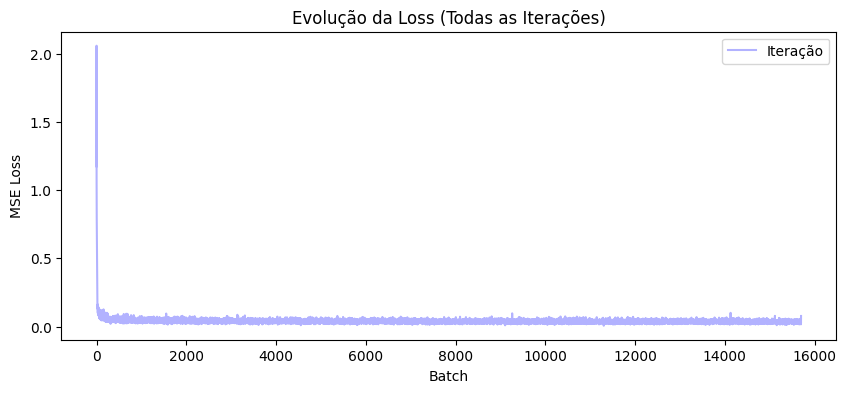

In [38]:
import matplotlib.pyplot as plt

# 1. Gráfico por Iteração (mostra todo o barulho do treino)
plt.figure(figsize=(10, 4))
plt.plot(history["iteration_losses"], alpha=0.3, color='blue', label='Iteração')
plt.title("Evolução da Loss (Todas as Iterações)")
plt.xlabel("Batch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()



A pintar...: 100%|██████████| 1000/1000 [00:09<00:00, 101.62it/s]


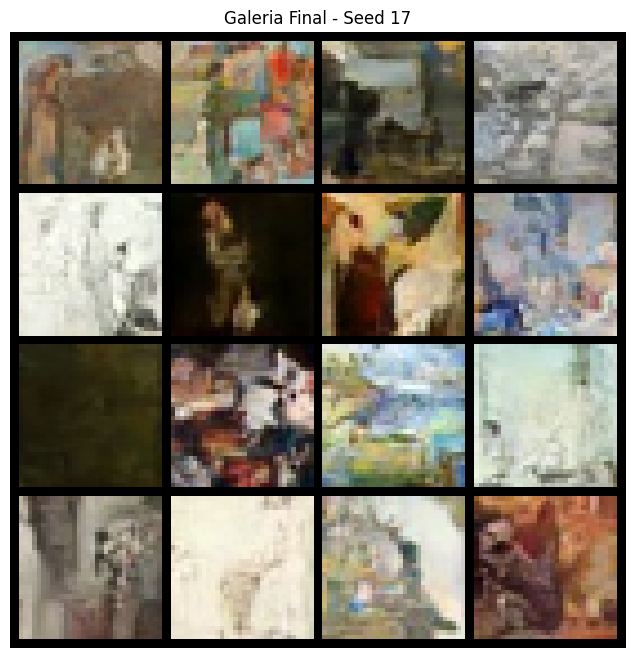

In [40]:
def ver_amostras_seed(seed_escolhida, n_images=16):
    # 1. Carregar modelo
    model = SimpleDiffusionUNet(down_channels=(64, 128, 256), time_emb_dim=64).to(DEVICE)
    model.load_state_dict(torch.load(f"diffusion__optuna__final_seed_{seed_escolhida}.pth"))
    model.eval()
    
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
    
    # 2. Gerar
    img = torch.randn((n_images, 3, 32, 32), device=DEVICE)
    for t in tqdm(reversed(range(1000)), total=1000, desc="A pintar..."):
        t_batch = torch.full((n_images,), t, device=DEVICE).long()
        with torch.no_grad():
            noise_pred = model(img, t_batch)
            img = noise_scheduler.step(noise_pred, t, img).prev_sample
            
    # 3. Mostrar
    img = (img.clamp(-1, 1) * 0.5 + 0.5).cpu()
    grid = make_grid(img, nrow=4).permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid)
    plt.axis('off')
    plt.title(f"Galeria Final - Seed {seed_escolhida}")
    plt.show()

# Basta chamares assim:
ver_amostras_seed(17)

A carregar modelos de: C:\Users\Jose\Mestrado\IAG_TP1\results

🚀 Gerando amostras para a Seed 3...


Denoising: 100%|██████████| 1000/1000 [00:09<00:00, 107.70it/s]


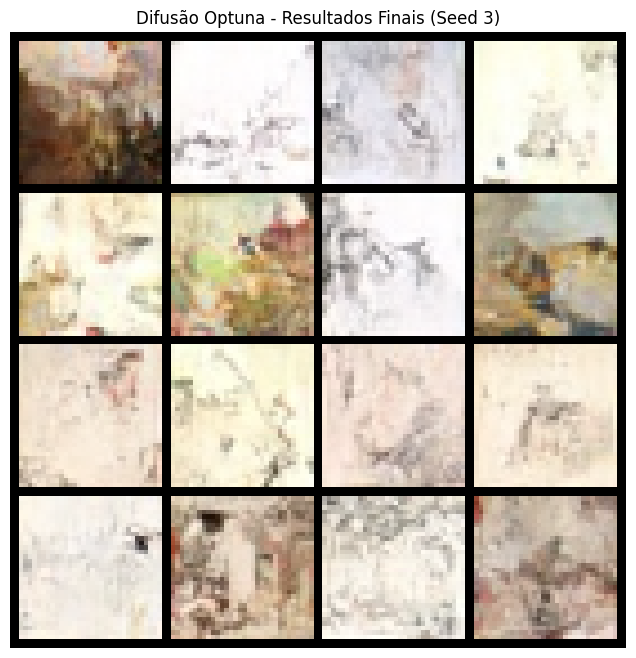


🚀 Gerando amostras para a Seed 17...


Denoising: 100%|██████████| 1000/1000 [00:09<00:00, 111.07it/s]


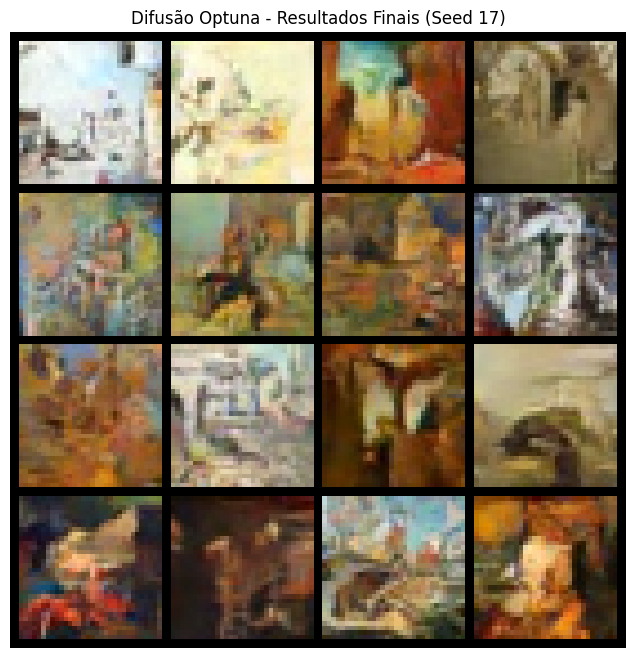


🚀 Gerando amostras para a Seed 29...


Denoising: 100%|██████████| 1000/1000 [00:09<00:00, 110.45it/s]


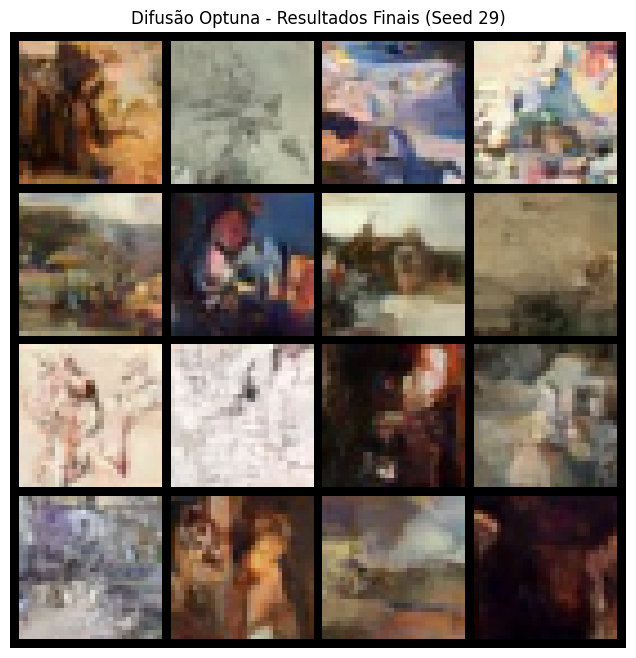


🚀 Gerando amostras para a Seed 58...


Denoising: 100%|██████████| 1000/1000 [00:08<00:00, 111.26it/s]


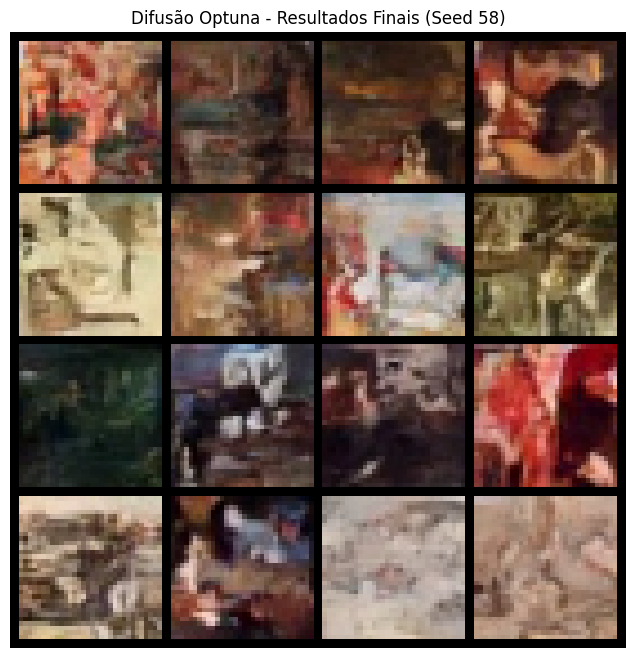


🚀 Gerando amostras para a Seed 71...


Denoising: 100%|██████████| 1000/1000 [00:09<00:00, 111.10it/s]


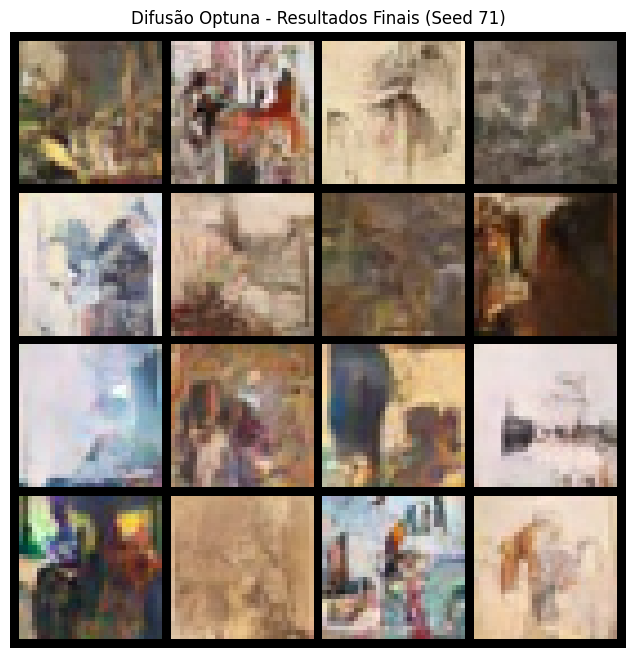


🚀 Gerando amostras para a Seed 89...


Denoising: 100%|██████████| 1000/1000 [00:09<00:00, 111.03it/s]


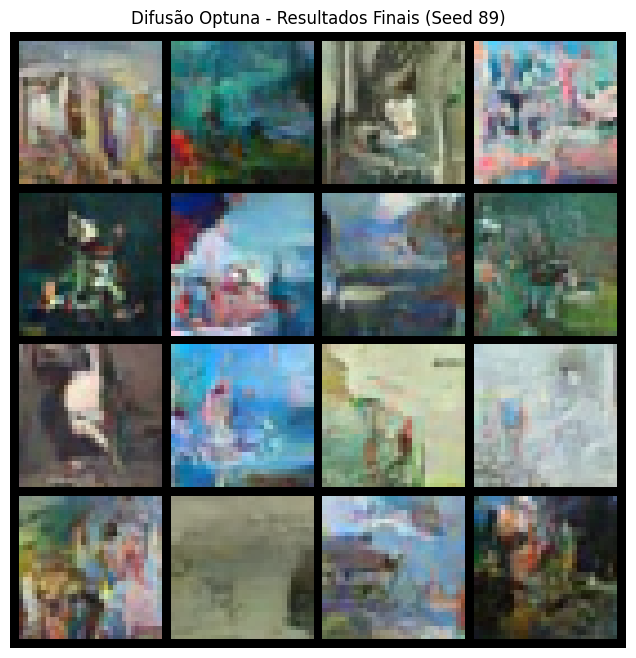


🚀 Gerando amostras para a Seed 123...


Denoising: 100%|██████████| 1000/1000 [00:08<00:00, 111.17it/s]


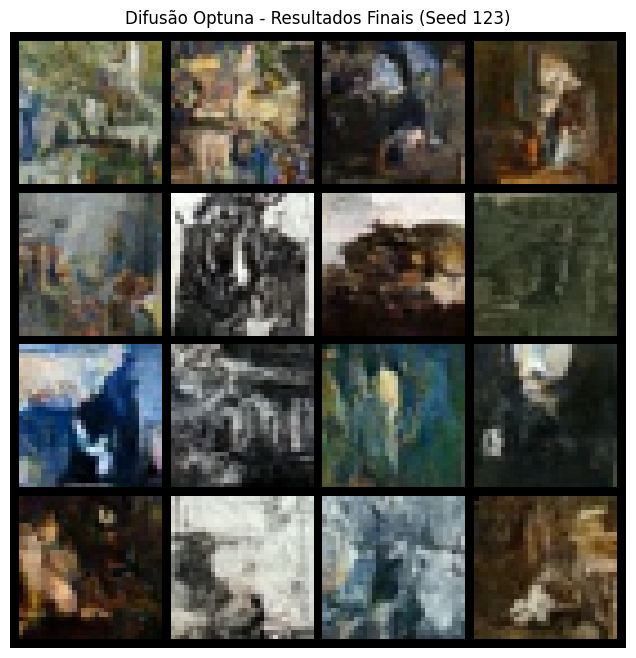


🚀 Gerando amostras para a Seed 256...


Denoising: 100%|██████████| 1000/1000 [00:08<00:00, 115.26it/s]


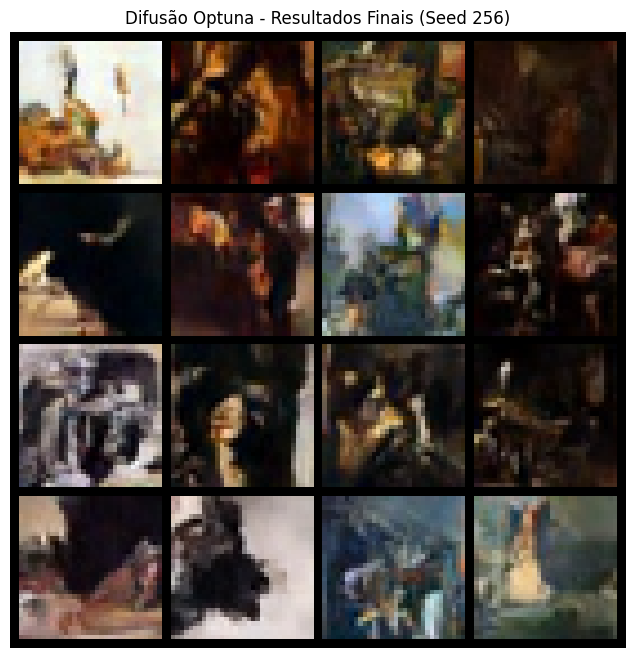


🚀 Gerando amostras para a Seed 456...


Denoising: 100%|██████████| 1000/1000 [00:08<00:00, 118.49it/s]


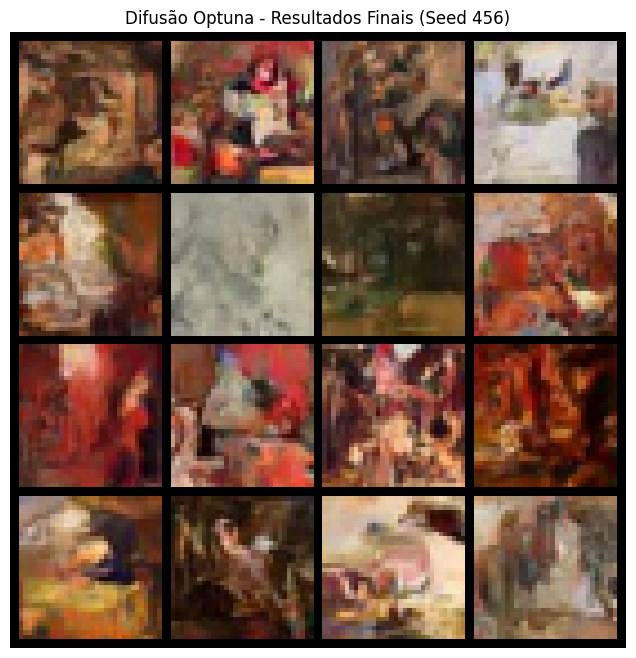


🚀 Gerando amostras para a Seed 512...


Denoising: 100%|██████████| 1000/1000 [00:08<00:00, 119.91it/s]


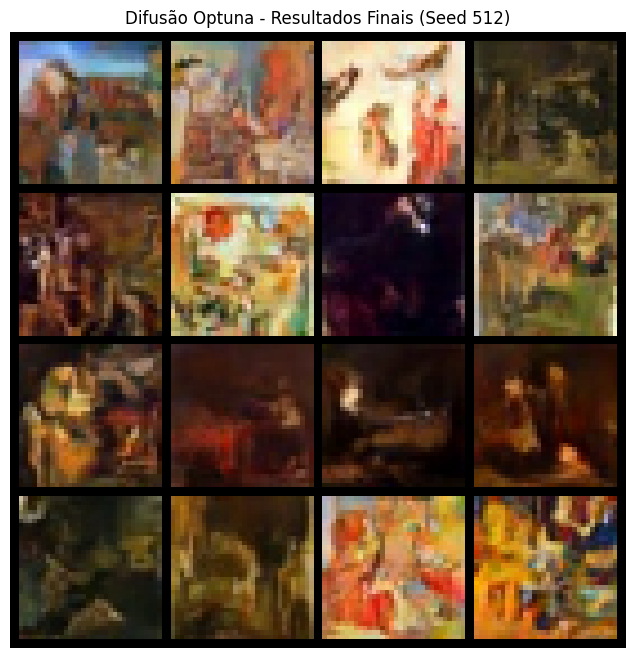

In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from pathlib import Path
from diffusers import DDPMScheduler
from tqdm import tqdm

@torch.no_grad()
def load_and_visualize_diffusion(seeds_list, results_path, n_samples=16):
    # 1. Instanciar a arquitetura com os parâmetros vencedores do Optuna
    # O erro 'size mismatch' acontecia porque o modelo treinado tinha time_dim=64
    model = SimpleDiffusionUNet(
        down_channels=(64, 128, 256), 
        time_emb_dim=64
    ).to(DEVICE)
    
    results_path = Path(results_path)
    
    # 2. Configurar o Scheduler (usando a biblioteca para evitar erros manuais)
    # Usamos 'linear' porque foi o que o teu Optuna escolheu como melhor
    noise_scheduler = DDPMScheduler(
        num_train_timesteps=1000, 
        beta_schedule="linear"
    )
    
    print(f"A carregar modelos de: {results_path}")

    for seed in seeds_list:
        # Procurar o ficheiro .pth da seed específica
        model_file = results_path / f"diffusion_optuna_seed{seed}.pth"
        
        if not model_file.exists():
            print(f"Ficheiro não encontrado: {model_file.name}")
            continue
            
        print(f"\n amostras para a Seed {seed}...")
        
        # CARREGAR OS PESOS
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        model.eval()
        
        # PROCESSO DE DENOISING (Processo Reverso)
        # Começamos com ruído puro [Batch, Canais, Altura, Largura]
        img = torch.randn((n_samples, 3, 32, 32), device=DEVICE)
        
        # Loop reverso de T-1 até 0
        for t in tqdm(reversed(range(1000)), total=1000, desc="Denoising"):
            t_batch = torch.full((n_samples,), t, device=DEVICE).long()
            
            # 1. Prever o ruído com o modelo
            noise_pred = model(img, t_batch)
            
            # 2. Passo do Scheduler: Calcula x_{t-1} a partir de x_t e do ruído previsto
            # O .prev_sample extrai o tensor da imagem resultante
            img = noise_scheduler.step(noise_pred, t, img).prev_sample
        
        # Formatação final para visualização
        # O scheduler já costuma manter o range próximo de [-1, 1]
        img = (img.clamp(-1, 1) + 1) / 2
        grid = make_grid(img, nrow=4, padding=2).permute(1, 2, 0).cpu().numpy()
        
        plt.figure(figsize=(8, 8))
        plt.imshow(grid)
        plt.axis('off')
        plt.title(f"Difusão Optuna - Resultados Finais (Seed {seed})")
        plt.show()

# --- EXECUÇÃO ---
resultados = r"C:\Users\Jose\Mestrado\IAG_TP1\results"
seeds_para_testar = [3, 17, 29] #, 58, 71, 89, 123, 256, 456, 512]

load_and_visualize_diffusion(seeds_para_testar, resultados, n_samples=5000)


AVALIAÇÃO SEED 3 | Alvo: 1000 amostras
-> A carregar imagens REAIS do dataset...


Gerando 1000 fakes: 100%|██████████| 1000/1000 [09:04<00:00,  1.84it/s]



[FINAL SEED 3] FID: 115.27 | KID: 0.0770


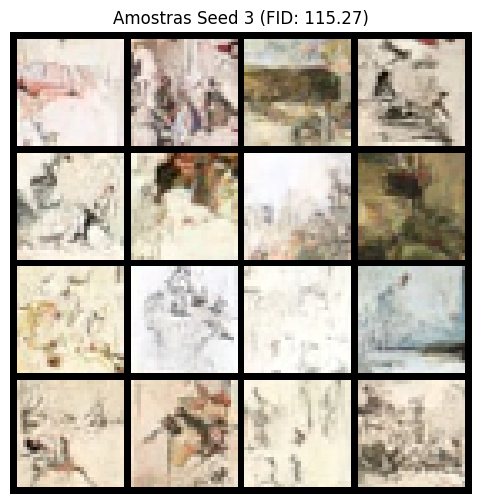


AVALIAÇÃO SEED 17 | Alvo: 1000 amostras
-> A carregar imagens REAIS do dataset...


Gerando 1000 fakes: 100%|██████████| 1000/1000 [08:51<00:00,  1.88it/s]



[FINAL SEED 17] FID: 79.45 | KID: 0.0386


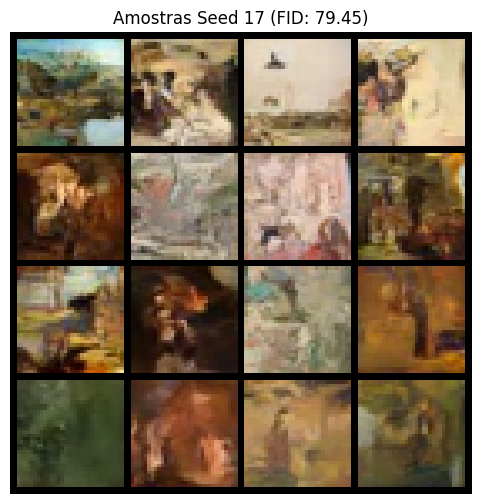


AVALIAÇÃO SEED 29 | Alvo: 1000 amostras
-> A carregar imagens REAIS do dataset...


Gerando 1000 fakes: 100%|██████████| 1000/1000 [08:18<00:00,  2.01it/s]



[FINAL SEED 29] FID: 80.33 | KID: 0.0413


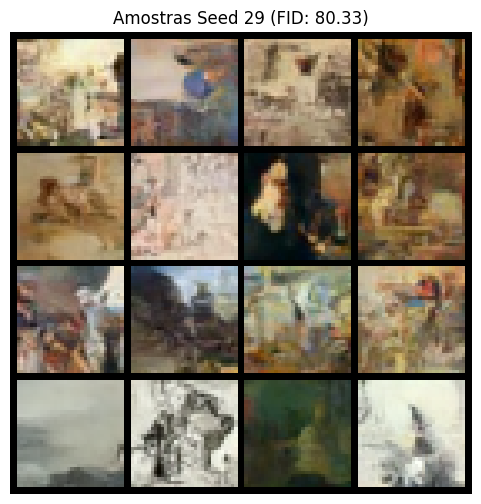

In [31]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from pathlib import Path
from diffusers import DDPMScheduler
from tqdm import tqdm

@torch.no_grad()
def evaluate_diffusion_quick_test(seeds_list, results_path, target_samples=1000, batch_size=64):
    """
    Executa um teste de 1000 imagens por seed. 
    Inclui o carregamento automático de imagens reais para evitar erro no FID.
    """
    # 1. Instanciar a arquitetura (conforme o teu treino)
    model = SimpleDiffusionUNet(
        down_channels=(64, 128, 256), 
        time_emb_dim=64
    ).to(DEVICE)
    
    results_path = Path(results_path)
    
    # 2. Configurar o Scheduler
    noise_scheduler = DDPMScheduler(
        num_train_timesteps=1000, 
        beta_schedule="linear"
    )

    all_seed_results = []
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    kid_metric = KernelInceptionDistance(subset_size=100).to(DEVICE)
    for seed in seeds_list:
        model_file = results_path / f"diffusion_optuna_seed{seed}.pth"
        if not model_file.exists():
            print(f"Ficheiro não encontrado: {model_file.name}")
            continue
            
        print(f"\n{'='*40}")
        print(f"AVALIAÇÃO SEED {seed} | Alvo: {target_samples} amostras")
        print(f"{'='*40}")
        
        # Carregar pesos e colocar em modo eval
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        model.eval()

        # --- PASSO A: Reset e Carregamento de Imagens REAIS ---
        # Isto resolve o erro "More than one sample is required"
        fid_metric.reset()
        kid_metric.reset()
        
        print(f"-> A carregar imagens REAIS do dataset...")
        real_count = 0
        for x, *_ in train_loader:
            x = x.to(DEVICE)
            real_uint8 = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
            fid_metric.update(real_uint8, real=True)
            kid_metric.update(real_uint8, real=True)
            real_count += x.size(0)
            if real_count >= 5000: # O protocolo pede 5000 reais
                break

        # --- PASSO B: Geração de Imagens FALSAS (Amostragem) ---
        samples_collected = 0
        first_batch_imgs = None 

        pbar = tqdm(total=target_samples, desc=f"Gerando {target_samples} fakes")
        while samples_collected < target_samples:
            current_batch_size = min(batch_size, target_samples - samples_collected)
            
            # Ruído inicial
            img = torch.randn((current_batch_size, 3, 32, 32), device=DEVICE)
            
            # Loop de Denoising (1000 passos)
            for t in reversed(range(1000)):
                t_batch = torch.full((current_batch_size,), t, device=DEVICE).long()
                noise_pred = model(img, t_batch)
                img = noise_scheduler.step(noise_pred, t, img).prev_sample
            
            # Guardar visualização do primeiro lote
            if first_batch_imgs is None:
                first_batch_imgs = img[:16].detach().cpu()

            # Converter para uint8 e atualizar métrica (real=False)
            img_uint8 = ((img.clamp(-1, 1) * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(img_uint8, real=False)
            kid_metric.update(img_uint8, real=False)
            
            samples_collected += current_batch_size
            pbar.update(current_batch_size)
        
        pbar.close()

        # --- PASSO C: Cálculo Final ---
        fid_val = fid_metric.compute().item()
        kid_mean, _ = kid_metric.compute()
        
        print(f"\n[FINAL SEED {seed}] FID: {fid_val:.2f} | KID: {kid_mean.item():.4f}")
        
        # Visualização
        vis_grid = (first_batch_imgs.clamp(-1, 1) * 0.5 + 0.5)
        grid = make_grid(vis_grid, nrow=4, padding=2).permute(1, 2, 0).numpy()
        
        plt.figure(figsize=(6, 6))
        plt.imshow(grid)
        plt.axis('off')
        plt.title(f"Amostras Seed {seed} (FID: {fid_val:.2f})")
        plt.show()

        all_seed_results.append({"seed": seed, "fid": fid_val, "kid": kid_mean.item()})

    return all_seed_results

# --- EXECUÇÃO ---
# Ajusta o caminho para a tua pasta de resultados
resultados_dir = r"C:\Users\Jose\Mestrado\IAG_TP1\results"
seeds_teste = [3, 17, 29] 

# Chama a função
resumos = evaluate_diffusion_quick_test(seeds_teste, resultados_dir, target_samples=1000, batch_size=64)